# The three demo scenarios — run them one at a time

This notebook produces **every file the public demonstration reads**, by running the three
prebuilt scenarios through the real optimisation model, one section at a time.

It replaces the placeholders. Until now `demo/experiments/results/S1|S2|S3/` held mocks
written by [`mock_results.py`](../demo/experiments/mock_results.py) — a greedy heuristic,
stamped `"placeholder": true` — because no Gurobi licence was available. With a licence in
place the same directories are filled, file for file, by the actual solver.

**This re-run's goal**: regenerate every design and result with the Phase B exports —
the model's own decision plan (`model_plan.json`), the instance it solved
(`instance.json`), the routed bike arcs it used (`results/shared/bike_arcs.json`) — and
an `instance`-mode simulation that replays the model's own demand against its own
design, with the `src_commit` of `network-design-bss/src/` that produced each file
recorded in its own provenance block.

**The pipeline, per scenario:**

| Stage | Code | Writes |
|---|---|---|
| 1. Design | the frozen model in [`network-design-bss/src/`](../network-design-bss/src), driven by `run_model.run_scenario` | `stations.json`, `metrics.json`, `instance.json`, `model_plan.json` |
| 2. Day simulation | [`simulate.py`](../demo/experiments/simulate.py) — observed trips replayed against the design, plus the model's own day | `sim_monday.json`, `sim_sunday.json`, `sim_monday_x25.json`, `sim_instance.json` |
| 3. KPIs | [`evaluate.py`](../demo/experiments/evaluate.py) | `kpis.json` |

**The three scenarios differ only in money**, so every KPI difference is attributable to
the budget decision. They share the seed, the demand table and the period weights
`0.169 / 0.343 / 0.488` measured from the observed trips.

| | S1 Essential | S2 Balanced | S3 Ambitious |
|---|---|---|---|
| Total budget | 20 000 € | 80 000 € | 140 000 € |
| Operational ratio | 2.5 % | 2.5 % | 5 % |
| Stages | Who is left out? | The reference plan | Is more always better? |

> **Timing.** The first scenario pays a cold shortest-path enumeration (~50 min). That
> stage is cached on disk under keys carrying **no scenario parameter**, so S2 and S3
> reuse it and take minutes. Run the sections in order the first time.


## Step 0 — Prepare the process

[`network-design-bss/src/`](../network-design-bss/src) is Zhenyu WU's optimisation model,
treated as **read-only** so its results stay attributable to the code as submitted. Two
things follow from that, and both are handled for you:

- `compat.bootstrap()` (in the SDK, outside the frozen tree) puts the model on `sys.path`,
  changes the working directory into it, and patches four defects at runtime.
- The scenario parameters are **not** applied by editing `instance_builder.py`, as
  `scenarios/README.md` describes. [`run_model.py`](../demo/experiments/run_model.py)
  swaps `generate_h3_instances()` in `sys.modules` for the duration of one run, so the
  file on disk is never touched and `git diff` stays empty — nothing to remember to revert.

In [1]:
import pathlib, sys

# Tolerate re-running this cell after bootstrap() has already moved us.
REPO = pathlib.Path.cwd()
while not (REPO / "network-design-bss" / "sdk-builder").is_dir():
    if REPO.parent == REPO:
        raise FileNotFoundError("repository root not found above " + str(pathlib.Path.cwd()))
    REPO = REPO.parent

for path in (REPO, REPO / "network-design-bss" / "sdk-builder"):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

print("repository:", REPO)
print("python    :", sys.version.split()[0])

repository: /Users/rebeca/INRIA/projects/SUM/research/development/sum-network-design-bike-sharing
python    : 3.13.15


### The Gurobi licence

The integrated solve is a mixed-integer program well past the 2 000 variables / 2 000
constraints of the licence bundled with `gurobipy`. The cell below fails loudly now
rather than after the expensive network stage has already run.

In [2]:
import gurobipy as gp

probe = gp.Model("licence-probe")
probe.addVars(5000, vtype="B")
probe.update()
print(f"gurobipy {'.'.join(str(v) for v in gp.gurobi.version())}"
      f" — {probe.NumVars} binary variables accepted (a size-limited licence stops at 2000)")
probe.dispose()

Set parameter Username
Set parameter LicenseID to value 2861409
Academic license - for non-commercial use only - expires 2027-09-08
gurobipy 13.0.3 — 5000 binary variables accepted (a size-limited licence stops at 2000)


## Step 1 — Derived data the simulator reads

These four scripts turn the observed layers in
[`demo/experiments/data/geneva_1.5km-radius/`](../demo/experiments/data/geneva_1.5km-radius)
into the small derived files the simulator and the KPIs need. They depend on no scenario,
so they run once, before anything else.

| Script | Produces | What it measures |
|---|---|---|
| `trips.py` | `data/calibration.json` | daily trip volumes per day type — the simulator's base demand |
| `profiles.py` | `data/profiles.json` | Monday/Sunday hourly profiles and the model's period weights |
| `ridership.py` | `data/pt_ridership_summary.json` | real PT boardings; cross-checks the trips' timezone reading |
| `stations_real.py` | `data/stations_real.geojson` | today's network with real GBFS capacities (map layer) |

In [3]:
from demo.experiments import trips, profiles, ridership, stations_real

calibration = trips.build_calibration()
profile_data = profiles.build_profiles()
pt_summary = ridership.build_summary()
real_network, match_report = stations_real.build_stations_real()

print("\nperiod weights (06-10 / 10-16 / 16-22), weekday:",
      profile_data["period_weights"]["weekday"])

calibration written -> /Users/rebeca/INRIA/projects/SUM/research/development/sum-network-design-bike-sharing/demo/experiments/data/calibration.json
profiles written -> /Users/rebeca/INRIA/projects/SUM/research/development/sum-network-design-bike-sharing/demo/experiments/data/profiles.json
PT ridership summary -> /Users/rebeca/INRIA/projects/SUM/research/development/sum-network-design-bike-sharing/demo/experiments/data/pt_ridership_summary.json
stations_real: 128/139 matched with real capacity (115 by name, 13 by proximity) -> /Users/rebeca/INRIA/projects/SUM/research/development/sum-network-design-bike-sharing/demo/experiments/data/stations_real.geojson
no capacity (likely discontinued): 11 stations: Bonivard, El Pueblo, Ferdinand-Hodler 17, Fribourg 2, Musée d'Art et Histoire, Muzy 7, Rue Thalberg 8, Rue d'Italie ...

period weights (06-10 / 10-16 / 16-22), weekday: [0.169, 0.343, 0.488]


The weekday period weights printed above are the ones written into each scenario's
`model_parameters.period_weights` — the observed commute rhythm, replacing the
`np.random.dirichlet` draw of the committed code.

In [4]:
from demo.experiments.ridership import validate_bike_timezone

# The trip timestamps are naive strings in a field named `trip_started_at_utc`. Reading
# them as UTC puts the morning peak at 08h local; reading them naively puts it at 06h,
# which is not credible for commuting. PT ridership is in local time by construction, so
# its peaks are an independent check on that reading.
print(validate_bike_timezone())

{'pt_weekday_peak_hours': [17, 18, 16], 'bike_weekday_peak_hours_after_utc_conversion': [18, 17, 8], 'consistent': True}


## Step 2 — The per-scenario pipeline

One function, so each scenario section below is a single call and the three are run
identically. It performs the three stages of the table at the top and returns the KPIs.

The four simulated days are the demonstration's data contract:

- **`monday`** and **`sunday`** — *replay* mode: the actual recorded trips, at their
  recorded local times and coordinates, averaged over every observed day of that type.
  No synthetic demand. This is the proof mode.
- **`monday_x25`** — *sample* mode at 25× the measured volume over 5 seeds. At today's
  observed ~11.5 trips/day every reasonable design serves ~100 %, so the scenarios only
  separate under growth. This is a **labelled hypothesis**, not an observation.
- **`instance`** — *instance* mode: the model's own demand — the 1,453 trips of the
  solved instance, placed at cell centres and spread across each period's hours by the
  observed profile — replayed against the same design, following the model's own
  station assignment, rebalancing plan and bike arcs when `model_plan.json` /
  `results/shared/bike_arcs.json` have been exported (falling back to nearest-station
  choice, greedy restore and haversine × 1.3 otherwise, and saying so in the `method`
  block). This is the only day sized the way the model was; see Step 7.


In [5]:
import json

from demo.experiments import RESULTS_DIR
from demo.experiments.run_model import run_scenario, load_scenario
from demo.experiments.simulate import simulate_day
from demo.experiments.evaluate import evaluate_scenario

#: (file suffix, simulate_day kwargs) for the days every design is tested against.
SIM_DAYS = (
    ("monday",     dict(day="monday", mode="replay")),
    ("sunday",     dict(day="sunday", mode="replay")),
    ("monday_x25", dict(day="monday", mode="sample", scale=25.0, seeds=5)),
    ("instance",   dict(day="monday", mode="instance", seeds=5)),
)


def run_full_scenario(scenario_id, days=SIM_DAYS):
    """Design, simulate and evaluate one scenario; write its results directory."""
    scenario = load_scenario(scenario_id)
    print(f"=== {scenario['id']} — {scenario['title']} ===")
    print(f"{scenario['audience_pitch']}\n")

    design = run_scenario(scenario_id)          # stations.json + metrics.json
    out_dir = design["out_dir"]
    stations_file = out_dir / "stations.json"

    # Phase B exports: instance.json is written by every run; model_plan.json and
    # results/shared/bike_arcs.json only appear once this scenario has been solved
    # with the Phase B export code, i.e. after the user's next Gurobi run.
    instance_file = out_dir / "instance.json"
    model_plan_file = out_dir / "model_plan.json"
    bike_arcs_file = RESULTS_DIR / "shared" / "bike_arcs.json"
    for label, path in (("instance.json  ", instance_file),
                        ("model_plan.json", model_plan_file),
                        ("bike_arcs.json ", bike_arcs_file)):
        status = "present" if path.is_file() else "missing — needs the Phase B export run"
        print(f"  {label}: {path}  ({status})")
    if model_plan_file.is_file():
        summary = json.loads(model_plan_file.read_text())["summary"]
        print("  model_plan.json summary:")
        for key, value in summary.items():
            print(f"    {key:<22} {value}")

    for suffix, kwargs in days:
        simulate_day(stations_file,
                     output_file=out_dir / f"sim_{suffix}.json", **kwargs)

    kpis = evaluate_scenario(out_dir)  # kpis.json
    return design, kpis


In [6]:
import pandas as pd
from IPython.display import Markdown, display


def show_scenario(design, kpis, day="monday"):
    """Print the headline of one finished scenario."""
    run = design["provenance"]["run"]
    stations = design["stations"]
    display(Markdown(
        f"**{design['title']}** — solver status {run['gurobi_status']} "
        f"(2 = optimal), MIP gap {run['mip_gap']:.2%}, "
        f"{run['n_variables']:,} variables / {run['n_constraints']:,} constraints, "
        f"{run['wall_clock_s'] / 60:.1f} min.<br>"
        f"**{len(stations)} stations**, {sum(s['capacity'] for s in stations):.0f} docks, "
        f"{sum(s['initial_bikes'] for s in stations):.0f} bikes."))

    display(pd.DataFrame([design["metrics"]]).T.rename(columns={0: "model metric"}))

    d = kpis["days"][day]
    display(pd.DataFrame({
        "service": pd.Series(d["service"]), "mobility": pd.Series(d["mobility"]),
        "environment": pd.Series(d["environment"]), "economics": pd.Series(d["economics"]),
    }).dropna(how="all").fillna(""))

    return pd.DataFrame(stations).head(10)

## Step 3 — S1 — Essential network

The city invests the minimum (20 000 €). With so little money the optimiser has to triage: it concentrates stations where demand and public-transport connections pay off most, and whole neighbourhoods stay uncovered. **If the shortest-path cache is cold, this is the scenario that pays for building it (~50 min); S2 and S3 then reuse it and take minutes.** The cache is shared with the other notebooks in this folder, so it may already be warm.


In [7]:
s1_essential_design, s1_essential_kpis = run_full_scenario("S1_essential")

=== S1_essential — Essential network ===
The city invests the minimum. Where do the few stations go, and who is left out?

[dedupe] route PT_2 duplicates PT_19, skipped.
[dedupe] route PT_G+ duplicates PT_E+, skipped.
[dedupe] route PT_G duplicates PT_E, skipped.
✅ Saved: h3_instances_json/Geneva_H3True_SEED20_DISmultinomial_P0.17-0.34-0.49_BUD20000_OP0.0250_SCALE1.00.txt
[network-design-bss] instance built in 0 s: 56 zones, 100 candidate stations, 973 demand entries
The total demand is 1453.
Period 0: total demand = 246, active OD pairs = 197, demand per OD = 1.25
Period 1: total demand = 482, active OD pairs = 340, demand per OD = 1.42
Period 2: total demand = 725, active OD pairs = 436, demand per OD = 1.66


/Users/rebeca/INRIA/projects/SUM/research/development/sum-network-design-bike-sharing/env/lib/python3.13/site-packages/contextily/tile.py:298: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tile_urls = [provider.build_url(x=tile.x, y=tile.y, z=tile.z) for tile in tiles]


[plot] Figure saved to: /Users/rebeca/INRIA/projects/SUM/research/development/sum-network-design-bike-sharing/network-design-bss/src/plot/H3_Grid_with_Candidate_Stations.png


/Users/rebeca/INRIA/projects/SUM/research/development/sum-network-design-bike-sharing/env/lib/python3.13/site-packages/contextily/tile.py:298: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tile_urls = [provider.build_url(x=tile.x, y=tile.y, z=tile.z) for tile in tiles]


[plot] PT stops figure saved to: /Users/rebeca/INRIA/projects/SUM/research/development/sum-network-design-bike-sharing/network-design-bss/src/plot/H3_Grid_with_PT_Stops.png
[SP cache] Loaded 11567 entries
Grid center walks to userOD processed: 1540 arcs added.

Grid center walks to publicTransportStop processed: 4592 arcs added.

Node: 
  - userOD: 56
  - publicTransportStop: 82

 Arc:
  - Walk: 18906
  - PT: 186
[SP cache] Saved 11567 entries
✅ Found file 'shortest_paths_cache_size7_k1_['real_pt_lines_radius2']_before.pkl', loading...
[SP cache] Loaded 11567 entries
Grid center walks to userOD processed: 0 arcs added.

Grid center walks to bikeStation processed: 193 arcs added.

Grid center walks to publicTransportStop processed: 110 arcs added.

PT stop walks to bike stations processed: 426 arcs added.

Biking processed: 2058 arcs added.

Node: 
  - userOD: 56
  - bikeStation: 100
  - publicTransportStop: 38

 Arc:
  - Walk: 1574
  - Bike: 4116
  - PT: 186
[SP cache] Saved 11567 entr

In [8]:
show_scenario(s1_essential_design, s1_essential_kpis)

**Essential network** — solver status 2 (2 = optimal), MIP gap 0.00%, 53,558 variables / 36,535 constraints, 0.3 min.<br>**35 stations**, 243 docks, 194 bikes.

,model metric
n_candidates,100.000000
n_selected_stations,35.000000
n_reg_station,29.000000
n_trans_station,6.000000
avg_capacity_reg,7.103448
avg_capacity_trans,6.166667
fill_ratio_reg,0.773455
fill_ratio_trans,0.761111
covered_od_ratio,0.388000
total_time_gain,2555.957983


,service,mobility,environment,economics
availability_ratio,0.766,,,
bike_trips_per_1000_pt_boardings,,0.04,,
bikes,194.0,,,
capex_eur,,,,20000.0
capex_eur_per_day_amortized,,,,6.85
car_km_avoided,,0.9,,
co2_avoided_kg_per_day,,,0.28,
co2_avoided_kg_per_year_extrapolated,,,103.0,
cost_per_served_trip_eur,,,,24.927
demand_trips,11.51,,,


,station,type,lon,lat,capacity,initial_bikes
0,BS-897a8dca1a3ffff,BikeStation,6.152308,46.211317,12.0,12.0
1,BS-897a8dcacd7ffff,BikeStation,6.153057,46.202358,11.0,5.0
2,BS-897a8dc123bffff,BikeStation,6.142942,46.202553,10.0,10.0
3,BS-897a8dc1273ffff,BikeStation,6.145097,46.206984,10.0,9.0
4,BS-897a8dc127bffff,BikeStation,6.147501,46.208429,10.0,3.0
5,transfer_PT_25-3,TransferStation,6.151519,46.203398,10.0,10.0
6,BS-897a8dc120bffff,BikeStation,6.142443,46.208527,9.0,9.0
7,BS-897a8dc126fffff,BikeStation,6.150403,46.203900,9.0,4.0
8,BS-897a8dc1277ffff,BikeStation,6.145346,46.203998,9.0,9.0
9,BS-897a8dc1247ffff,BikeStation,6.144847,46.209971,9.0,9.0


## Step 4 — S2 — Balanced network

The published Geneva proof-of-concept configuration (80 000 €, 2.5 % operational), with one change: the demand period weights are the ones observed in the trip data rather than random draws, so the design targets the actual morning and evening peaks. This is the reference plan — the one the other two are read against.


In [9]:
s2_balanced_design, s2_balanced_kpis = run_full_scenario("S2_balanced")

=== S2_balanced — Balanced network ===
The city funds a solid network -- the reference plan studied for Geneva.

[dedupe] route PT_2 duplicates PT_19, skipped.
[dedupe] route PT_G+ duplicates PT_E+, skipped.
[dedupe] route PT_G duplicates PT_E, skipped.
✅ Saved: h3_instances_json/Geneva_H3True_SEED20_DISmultinomial_P0.17-0.34-0.49_BUD80000_OP0.0250_SCALE1.00.txt
[network-design-bss] instance built in 0 s: 56 zones, 100 candidate stations, 973 demand entries
The total demand is 1453.
Period 0: total demand = 246, active OD pairs = 197, demand per OD = 1.25
Period 1: total demand = 482, active OD pairs = 340, demand per OD = 1.42
Period 2: total demand = 725, active OD pairs = 436, demand per OD = 1.66


/Users/rebeca/INRIA/projects/SUM/research/development/sum-network-design-bike-sharing/env/lib/python3.13/site-packages/contextily/tile.py:298: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tile_urls = [provider.build_url(x=tile.x, y=tile.y, z=tile.z) for tile in tiles]


[plot] Figure saved to: /Users/rebeca/INRIA/projects/SUM/research/development/sum-network-design-bike-sharing/network-design-bss/src/plot/H3_Grid_with_Candidate_Stations.png


/Users/rebeca/INRIA/projects/SUM/research/development/sum-network-design-bike-sharing/env/lib/python3.13/site-packages/contextily/tile.py:298: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tile_urls = [provider.build_url(x=tile.x, y=tile.y, z=tile.z) for tile in tiles]


[plot] PT stops figure saved to: /Users/rebeca/INRIA/projects/SUM/research/development/sum-network-design-bike-sharing/network-design-bss/src/plot/H3_Grid_with_PT_Stops.png
[SP cache] Loaded 11567 entries
Grid center walks to userOD processed: 1540 arcs added.

Grid center walks to publicTransportStop processed: 4592 arcs added.

Node: 
  - userOD: 56
  - publicTransportStop: 82

 Arc:
  - Walk: 18906
  - PT: 186
[SP cache] Saved 11567 entries
✅ Found file 'shortest_paths_cache_size7_k1_['real_pt_lines_radius2']_before.pkl', loading...
[SP cache] Loaded 11567 entries
Grid center walks to userOD processed: 0 arcs added.

Grid center walks to bikeStation processed: 193 arcs added.

Grid center walks to publicTransportStop processed: 110 arcs added.

PT stop walks to bike stations processed: 426 arcs added.

Biking processed: 2058 arcs added.

Node: 
  - userOD: 56
  - bikeStation: 100
  - publicTransportStop: 38

 Arc:
  - Walk: 1574
  - Bike: 4116
  - PT: 186
[SP cache] Saved 11567 entr

In [10]:
show_scenario(s2_balanced_design, s2_balanced_kpis)

**Balanced network** — solver status 2 (2 = optimal), MIP gap 0.00%, 53,558 variables / 36,535 constraints, 0.2 min.<br>**80 stations**, 1109 docks, 830 bikes.

,model metric
n_candidates,100.000000
n_selected_stations,80.000000
n_reg_station,49.000000
n_trans_station,31.000000
avg_capacity_reg,15.469388
avg_capacity_trans,11.322581
fill_ratio_reg,0.715674
fill_ratio_trans,0.626548
covered_od_ratio,0.925000
total_time_gain,7076.929099


,service,mobility,environment,economics
availability_ratio,0.875,,,
bike_trips_per_1000_pt_boardings,,0.05,,
bikes,830.0,,,
capex_eur,,,,79980.0
capex_eur_per_day_amortized,,,,27.39
car_km_avoided,,1.1,,
co2_avoided_kg_per_day,,,0.36,
co2_avoided_kg_per_year_extrapolated,,,131.0,
cost_per_served_trip_eur,,,,55.485
demand_trips,11.51,,,


,station,type,lon,lat,capacity,initial_bikes
0,BS-897a8dc123bffff,BikeStation,6.142942,46.202553,30.0,30.0
1,BS-897a8dc120bffff,BikeStation,6.142443,46.208527,30.0,24.0
2,BS-897a8dc126fffff,BikeStation,6.150403,46.203900,30.0,7.0
3,BS-897a8dca1a3ffff,BikeStation,6.152308,46.211317,30.0,30.0
4,BS-897a8dc1273ffff,BikeStation,6.145097,46.206984,30.0,26.0
5,BS-897a8dc1277ffff,BikeStation,6.145346,46.203998,30.0,30.0
6,BS-897a8dcaccfffff,BikeStation,6.158113,46.202260,30.0,24.0
7,BS-897a8dc1223ffff,BikeStation,6.143192,46.199567,30.0,24.0
8,transfer_PT_12-5,TransferStation,6.152867,46.201719,30.0,19.0
9,transfer_PT_25-2,TransferStation,6.156011,46.202291,30.0,30.0


## Step 5 — S3 — Ambitious green transition

The city goes all in: 140 000 € and double the operations money. The question the scenario stages is whether that is worth it — watch the cost per served trip against S2 rather than the absolute numbers, which will of course be larger.


In [11]:
s3_ambitious_design, s3_ambitious_kpis = run_full_scenario("S3_ambitious")

=== S3_ambitious — Ambitious green transition ===
The city goes all in: bigger budget, double the operations money. Is it worth it?

[dedupe] route PT_2 duplicates PT_19, skipped.
[dedupe] route PT_G+ duplicates PT_E+, skipped.
[dedupe] route PT_G duplicates PT_E, skipped.
✅ Saved: h3_instances_json/Geneva_H3True_SEED20_DISmultinomial_P0.17-0.34-0.49_BUD140000_OP0.0500_SCALE1.00.txt
[network-design-bss] instance built in 0 s: 56 zones, 100 candidate stations, 973 demand entries
The total demand is 1453.
Period 0: total demand = 246, active OD pairs = 197, demand per OD = 1.25
Period 1: total demand = 482, active OD pairs = 340, demand per OD = 1.42
Period 2: total demand = 725, active OD pairs = 436, demand per OD = 1.66


/Users/rebeca/INRIA/projects/SUM/research/development/sum-network-design-bike-sharing/env/lib/python3.13/site-packages/contextily/tile.py:298: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tile_urls = [provider.build_url(x=tile.x, y=tile.y, z=tile.z) for tile in tiles]


[plot] Figure saved to: /Users/rebeca/INRIA/projects/SUM/research/development/sum-network-design-bike-sharing/network-design-bss/src/plot/H3_Grid_with_Candidate_Stations.png


/Users/rebeca/INRIA/projects/SUM/research/development/sum-network-design-bike-sharing/env/lib/python3.13/site-packages/contextily/tile.py:298: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tile_urls = [provider.build_url(x=tile.x, y=tile.y, z=tile.z) for tile in tiles]


[plot] PT stops figure saved to: /Users/rebeca/INRIA/projects/SUM/research/development/sum-network-design-bike-sharing/network-design-bss/src/plot/H3_Grid_with_PT_Stops.png
[SP cache] Loaded 11567 entries
Grid center walks to userOD processed: 1540 arcs added.

Grid center walks to publicTransportStop processed: 4592 arcs added.

Node: 
  - userOD: 56
  - publicTransportStop: 82

 Arc:
  - Walk: 18906
  - PT: 186
[SP cache] Saved 11567 entries
✅ Found file 'shortest_paths_cache_size7_k1_['real_pt_lines_radius2']_before.pkl', loading...
[SP cache] Loaded 11567 entries
Grid center walks to userOD processed: 0 arcs added.

Grid center walks to bikeStation processed: 193 arcs added.

Grid center walks to publicTransportStop processed: 110 arcs added.

PT stop walks to bike stations processed: 426 arcs added.

Biking processed: 2058 arcs added.

Node: 
  - userOD: 56
  - bikeStation: 100
  - publicTransportStop: 38

 Arc:
  - Walk: 1574
  - Bike: 4116
  - PT: 186
[SP cache] Saved 11567 entr

In [12]:
show_scenario(s3_ambitious_design, s3_ambitious_kpis)

**Ambitious green transition** — solver status 2 (2 = optimal), MIP gap 0.00%, 53,558 variables / 36,535 constraints, 0.3 min.<br>**90 stations**, 2002 docks, 1516 bikes.

,model metric
n_candidates,100.000000
n_selected_stations,90.000000
n_reg_station,53.000000
n_trans_station,37.000000
avg_capacity_reg,23.641509
avg_capacity_trans,20.243243
fill_ratio_reg,0.727118
fill_ratio_trans,0.556379
covered_od_ratio,0.936000
total_time_gain,7229.789351


,service,mobility,environment,economics
availability_ratio,0.853,,,
bike_trips_per_1000_pt_boardings,,0.04,,
bikes,1516.0,,,
capex_eur,,,,140000.0
capex_eur_per_day_amortized,,,,47.95
car_km_avoided,,1.1,,
co2_avoided_kg_per_day,,,0.34,
co2_avoided_kg_per_year_extrapolated,,,125.0,
cost_per_served_trip_eur,,,,93.846
demand_trips,11.51,,,


,station,type,lon,lat,capacity,initial_bikes
0,BS-897a8dcac8fffff,BikeStation,6.153556,46.196384,30.0,28.0
1,BS-897a8dc1237ffff,BikeStation,6.140788,46.198122,30.0,30.0
2,BS-897a8dc1207ffff,BikeStation,6.140289,46.204096,30.0,25.0
3,BS-897a8dcacc3ffff,BikeStation,6.155460,46.203802,30.0,30.0
4,BS-897a8dc123bffff,BikeStation,6.142942,46.202553,30.0,30.0
5,BS-897a8dcac93ffff,BikeStation,6.148249,46.199469,30.0,30.0
6,BS-897a8dc1267ffff,BikeStation,6.148000,46.202455,30.0,7.0
7,BS-897a8dc120bffff,BikeStation,6.142443,46.208527,30.0,30.0
8,BS-897a8dc126fffff,BikeStation,6.150403,46.203900,30.0,6.0
9,BS-897a8dcac5bffff,BikeStation,6.162920,46.205148,30.0,19.0


## Step 6 — The human baseline

Before the optimiser, the design a person would sketch from the same data and the same
money: rank the zones by observed activity, put a station at the busiest ones, size them
all the same, stop when the budget runs out. No routing, no multimodal paths, no capacity
balanced over time.

It uses the same `stations.json` schema, so the same simulator replays it — which is what
makes the *"your plan vs the optimised plan, same euros"* moment of the demo possible.

Run this **after** the three scenarios, not before: `baseline.py` now chooses among the
**same 100 candidate stations the model considered**, read from S2's `instance.json`
(cell activity, uniform capacity, greedy fill, skipping candidates within 100 m of one
already chosen) instead of the raw 59-cell grid, so the human and the optimiser pick
from the same map. That file is written by the S2 step above; the assertion below fails
loudly, with a clear message, if this section is run out of order.


In [13]:
from demo.experiments import RESULTS_DIR
from demo.experiments.baseline import build_baseline

s2_instance_file = RESULTS_DIR / "S2_balanced" / "instance.json"
assert s2_instance_file.is_file(), (
    f"{s2_instance_file} is missing — run Step 4 (S2_balanced) before this step; "
    "the baseline now picks its stations from the model's own candidate set.")

baseline_dir = RESULTS_DIR / "baseline_20k"
build_baseline(20000, instance=s2_instance_file, output_file=baseline_dir / "stations.json")

for suffix, kwargs in SIM_DAYS:
    # The instance day needs to know which instance to replay; S1-S3 default to the
    # instance.json written next to their own stations.json, but baseline_20k has
    # none of its own, so point it at S2's -- the same one its candidates came from.
    extra = {"instance": s2_instance_file} if kwargs.get("mode") == "instance" else {}
    simulate_day(baseline_dir / "stations.json",
                 output_file=baseline_dir / f"sim_{suffix}.json", **kwargs, **extra)

baseline_kpis = evaluate_scenario(baseline_dir)


baseline design: 28 stations x 12 docks, 19600 EUR of 20000 EUR
written -> /Users/rebeca/INRIA/projects/SUM/research/development/sum-network-design-bike-sharing/demo/experiments/results/baseline_20k/stations.json
simulated monday [replay]: 9.78/11.51 trips served (daily mean) -> /Users/rebeca/INRIA/projects/SUM/research/development/sum-network-design-bike-sharing/demo/experiments/results/baseline_20k/sim_monday.json
simulated sunday [replay]: 7.94/9.44 trips served (daily mean) -> /Users/rebeca/INRIA/projects/SUM/research/development/sum-network-design-bike-sharing/demo/experiments/results/baseline_20k/sim_sunday.json
simulated monday [sample]: 253/288 trips served (daily mean) -> /Users/rebeca/INRIA/projects/SUM/research/development/sum-network-design-bike-sharing/demo/experiments/results/baseline_20k/sim_monday_x25.json
simulated instance [instance]: 467/1453 trips served (daily mean) -> /Users/rebeca/INRIA/projects/SUM/research/development/sum-network-design-bike-sharing/demo/experi

## Step 7 — Model vs simulator on the model's own day

Every other simulated day (`monday`, `sunday`, `monday_x25`) tests a design against
demand the model never saw: the observed trips are roughly 125× smaller than the
1,453-trip day S1–S3 were actually sized for
(`.specs/demo-pipeline/findings.md` #1), so a served-ratio gap between the model and
the simulator on those days mostly measures that scale mismatch, not agreement. The
`instance` day is the one apples-to-apples comparison: the simulator replays the
model's own demand, at the model's own periods, against the model's own design.

Read the table below as a spot-check, not a verdict:

- **Close numbers** mean the simulator's simpler behavioural engine (nearest-station
  choice, 2 retries, a greedy or replayed rebalancing round) reproduces what the
  solver assumed when it built the design.
- **A gap** does not automatically mean one view is wrong: the model maximises
  OD-pair coverage and time gain over ranked multimodal paths under budget
  constraints; the simulator counts individual trips served or lost to queueing-like
  failures (no bike, no dock) that the model's constraints do not represent directly.
- The `method` block in each scenario's `sim_instance.json` says which fallbacks were
  active: `rebalancing_source` and `ride_distance_source` read `"model"` once
  `model_plan.json` / `results/shared/bike_arcs.json` exist (after the next Gurobi
  run), `"greedy_restore"` / `"haversine"` before that; `station_choice` is
  `"model_assignment"` only when a plan is available. A row built entirely from
  fallbacks is a lower bound on agreement, not a disagreement with the model.


In [14]:
rows = []
for label in ("S1_essential", "S2_balanced", "S3_ambitious"):
    design_dir = RESULTS_DIR / label
    metrics = json.loads((design_dir / "metrics.json").read_text())
    kpis = json.loads((design_dir / "kpis.json").read_text())
    instance_day = kpis["days"].get("instance")
    if instance_day is None:
        rows.append({"scenario": label,
                     "instance day": "not simulated yet — re-run Steps 3-5 once the "
                                    "Phase B exports and mode=\"instance\" land"})
        continue

    model_view = instance_day.get("model_view", {})
    sim_instance = json.loads((design_dir / "sim_instance.json").read_text())
    method = sim_instance.get("method", {})

    rows.append({
        "scenario": label,
        "covered_od_ratio — model": metrics["covered_od_ratio"],
        "covered_od_ratio — simulated": model_view.get("covered_od_ratio"),
        "served flow — model (bike-only + bike+PT)":
            metrics["flow_bike_only"] + metrics["flow_bike_pt"],
        "served — simulated": instance_day["service"]["served_trips"],
        "dispatch_count — model": metrics["dispatch_count"],
        "truck_dispatches — simulated": sim_instance["rebalancing"]["truck_dispatches"],
        "utilisation — model (fill_ratio_reg proxy)": metrics["fill_ratio_reg"],
        "utilisation — simulated (model_view)": model_view.get("utilisation"),
        "rebalancing_source": method.get("rebalancing_source"),
        "ride_distance_source": method.get("ride_distance_source"),
        "station_choice": method.get("station_choice"),
    })

display(pd.DataFrame(rows).set_index("scenario").T)


scenario,S1_essential,S2_balanced,S3_ambitious
covered_od_ratio — model,0.388,0.925,0.936
covered_od_ratio — simulated,0.3936,0.5232,0.5206
served flow — model (bike-only + bike+PT),493.0,1263.0,1292.0
served — simulated,463.8,647.6,656.4
dispatch_count — model,0.0,2.0,3.0
truck_dispatches — simulated,0,2,3
utilisation — model (fill_ratio_reg proxy),0.773455,0.715674,0.727118
utilisation — simulated (model_view),0.7976,0.7071,0.6689
rebalancing_source,model_plan,model_plan,model_plan
ride_distance_source,model_bike_arcs,model_bike_arcs,model_bike_arcs


## Step 8 — The three scenarios side by side

The comparison the demonstration is built to stage, now printed for all four
simulated days. Read **`instance`** first: it is the only day whose demand matches
what these designs were actually sized for (1,453 trips vs. ~11.5/day observed —
`.specs/demo-pipeline/findings.md` #1), so it is the one comparison a served-ratio or
coverage gap between scenarios can be read at face value. `monday` and `sunday`
replay the *observed* trips — real, but ~125× smaller than the model's own day, so
every design saturates and the budgets barely separate; `monday_x25` restates that
same observation as an explicit demand-growth hypothesis. Whether `instance`
eventually replaces the observed replay as the primary view, or the two stay side by
side, is still an open decision (`.specs/demo-pipeline/plan.md` §8).


In [15]:
from demo.experiments.evaluate import compare

SCENARIO_DIRS = [RESULTS_DIR / s for s in ("S1_essential", "S2_balanced", "S3_ambitious")]
ALL_DIRS = SCENARIO_DIRS + [baseline_dir]

for day in ("instance", "monday", "monday_x25", "sunday"):
    display(Markdown(f"### {day}\n\n" + compare(ALL_DIRS, day=day)))


### instance

| KPI (instance) | S1_essential | S2_balanced | S3_ambitious | baseline_20k |
|---|---|---|---|---|
| Stations built | 35 | 80 | 90 | 28 |
| Docks | 243 | 1,109 | 2,002 | 336 |
| Bikes | 194 | 830 | 1,516 | 168 |
| Demand served | 0.319 | 0.446 | 0.452 | 0.321 |
| Spatial coverage | 0.878 | 0.959 | 0.959 | 0.844 |
| Availability (served if reachable) | 0.363 | 0.465 | 0.471 | 0.381 |
| Trips shifted from car / day | 46.4 | 64.8 | 65.6 | 46.7 |
| Car-km avoided / day | 31.8 | 45.0 | 45.3 | 29.4 |
| CO2 avoided kg / day | 10.17 | 14.38 | 14.49 | 9.38 |
| Investment (CAPEX, EUR) | 20,000 | 79,980 | 140,000 | 19,600 |
| Operating cost EUR / day | 97.0 | 619.18 | 1,056.68 | 655.06 |
| Revenue EUR / day | 927.6 | 1,295.2 | 1,312.8 | 934.0 |
| Cost per served trip EUR | 0.224 | 0.998 | 1.683 | 1.417 |
| Covered OD pairs (model definition) | 0.3936 | 0.5232 | 0.5206 | 0.334 |
| Utilisation (model definition) | 0.7976 | 0.7071 | 0.6689 | 0.5 |
| Borrowable rate (model definition) | 0.9919 | 0.9757 | 0.9649 | 0.9658 |

### monday

| KPI (monday) | S1_essential | S2_balanced | S3_ambitious | baseline_20k |
|---|---|---|---|---|
| Stations built | 35 | 80 | 90 | 28 |
| Docks | 243 | 1,109 | 2,002 | 336 |
| Bikes | 194 | 830 | 1,516 | 168 |
| Demand served | 0.703 | 0.875 | 0.853 | 0.85 |
| Spatial coverage | 0.917 | 1.0 | 1.0 | 0.85 |
| Availability (served if reachable) | 0.766 | 0.875 | 0.853 | 1.0 |
| Trips shifted from car / day | 0.8 | 1.0 | 1.0 | 1.0 |
| Car-km avoided / day | 0.9 | 1.1 | 1.1 | 1.1 |
| CO2 avoided kg / day | 0.28 | 0.36 | 0.34 | 0.34 |
| Investment (CAPEX, EUR) | 20,000 | 79,980 | 140,000 | 19,600 |
| Operating cost EUR / day | 194.81 | 531.34 | 873.62 | 188.2 |
| Revenue EUR / day | 16.18 | 20.14 | 19.64 | 19.56 |
| Cost per served trip EUR | 24.927 | 55.485 | 93.846 | 19.93 |
| Utilisation (model definition) | 0.7908 | 0.6982 | 0.657 | 0.5 |
| Borrowable rate (model definition) | 1.0 | 0.9625 | 0.9556 | 1.0 |

### monday_x25

| KPI (monday_x25) | S1_essential | S2_balanced | S3_ambitious | baseline_20k |
|---|---|---|---|---|
| Stations built | 35 | 80 | 90 | 28 |
| Docks | 243 | 1,109 | 2,002 | 336 |
| Bikes | 194 | 830 | 1,516 | 168 |
| Demand served | 0.715 | 0.892 | 0.916 | 0.878 |
| Spatial coverage | 0.922 | 1.0 | 1.0 | 0.893 |
| Availability (served if reachable) | 0.775 | 0.892 | 0.916 | 0.984 |
| Trips shifted from car / day | 20.6 | 25.7 | 26.4 | 25.3 |
| Car-km avoided / day | 24.6 | 31.9 | 32.7 | 31.1 |
| CO2 avoided kg / day | 7.86 | 10.19 | 10.46 | 9.92 |
| Investment (CAPEX, EUR) | 20,000 | 79,980 | 140,000 | 19,600 |
| Operating cost EUR / day | 625.92 | 1,517.57 | 1,880.06 | 940.73 |
| Revenue EUR / day | 411.6 | 513.6 | 527.6 | 506.0 |
| Cost per served trip EUR | 3.075 | 6.016 | 7.309 | 3.745 |
| Utilisation (model definition) | 0.7947 | 0.7065 | 0.6593 | 0.5 |
| Borrowable rate (model definition) | 0.9869 | 0.9667 | 0.956 | 0.9792 |

### sunday

| KPI (sunday) | S1_essential | S2_balanced | S3_ambitious | baseline_20k |
|---|---|---|---|---|
| Stations built | 35 | 80 | 90 | 28 |
| Docks | 243 | 1,109 | 2,002 | 336 |
| Bikes | 194 | 830 | 1,516 | 168 |
| Demand served | 0.682 | 0.889 | 0.859 | 0.841 |
| Spatial coverage | 0.924 | 1.0 | 1.0 | 0.841 |
| Availability (served if reachable) | 0.739 | 0.889 | 0.859 | 1.0 |
| Trips shifted from car / day | 0.6 | 0.8 | 0.8 | 0.8 |
| Car-km avoided / day | 0.7 | 0.9 | 0.9 | 0.8 |
| CO2 avoided kg / day | 0.21 | 0.28 | 0.28 | 0.25 |
| Investment (CAPEX, EUR) | 20,000 | 79,980 | 140,000 | 19,600 |
| Operating cost EUR / day | 206.5 | 551.69 | 888.13 | 197.42 |
| Revenue EUR / day | 12.88 | 16.78 | 16.22 | 15.88 |
| Cost per served trip EUR | 33.129 | 69.02 | 115.422 | 25.709 |
| Utilisation (model definition) | 0.7929 | 0.6988 | 0.6571 | 0.5 |
| Borrowable rate (model definition) | 1.0 | 0.9625 | 0.9556 | 1.0 |

In [16]:
import json

rows = []
for directory in ALL_DIRS:
    kpis = json.loads((directory / "kpis.json").read_text())
    for day, d in kpis["days"].items():
        rows.append({
            "scenario": kpis["scenario"], "day": day,
            "budget_eur": d["economics"]["capex_eur"],
            "stations": d["service"]["stations"],
            "bikes": d["service"]["bikes"],
            "served_ratio": d["service"]["served_ratio"],
            "coverage": d["service"]["spatial_coverage_ratio"],
            "availability": d["service"]["availability_ratio"],
            "co2_kg_per_day": d["environment"]["co2_avoided_kg_per_day"],
            "cost_per_served_trip_eur": d["economics"]["cost_per_served_trip_eur"],
        })

summary = pd.DataFrame(rows).sort_values(["day", "budget_eur"])
summary

,scenario,day,budget_eur,stations,bikes,served_ratio,coverage,availability,co2_kg_per_day,cost_per_served_trip_eur
12,baseline_20k,instance,19600,28,168,0.321,0.844,0.381,9.38,1.417
0,S1_essential,instance,20000,35,194,0.319,0.878,0.363,10.17,0.224
4,S2_balanced,instance,79980,80,830,0.446,0.959,0.465,14.38,0.998
8,S3_ambitious,instance,140000,90,1516,0.452,0.959,0.471,14.49,1.683
13,baseline_20k,monday,19600,28,168,0.850,0.850,1.000,0.34,19.930
1,S1_essential,monday,20000,35,194,0.703,0.917,0.766,0.28,24.927
5,S2_balanced,monday,79980,80,830,0.875,1.000,0.875,0.36,55.485
9,S3_ambitious,monday,140000,90,1516,0.853,1.000,0.853,0.34,93.846
14,baseline_20k,monday_x25,19600,28,168,0.878,0.893,0.984,9.92,3.745
2,S1_essential,monday_x25,20000,35,194,0.715,0.922,0.775,7.86,3.075


### Diminishing returns, made visible

The point S3 exists to make: plotted against money, served trips flatten while cost per
served trip climbs. Under the ×25 growth hypothesis — the only demand level at which the
budgets separate at all — that trade-off is the whole argument for optimising rather than
simply spending more.

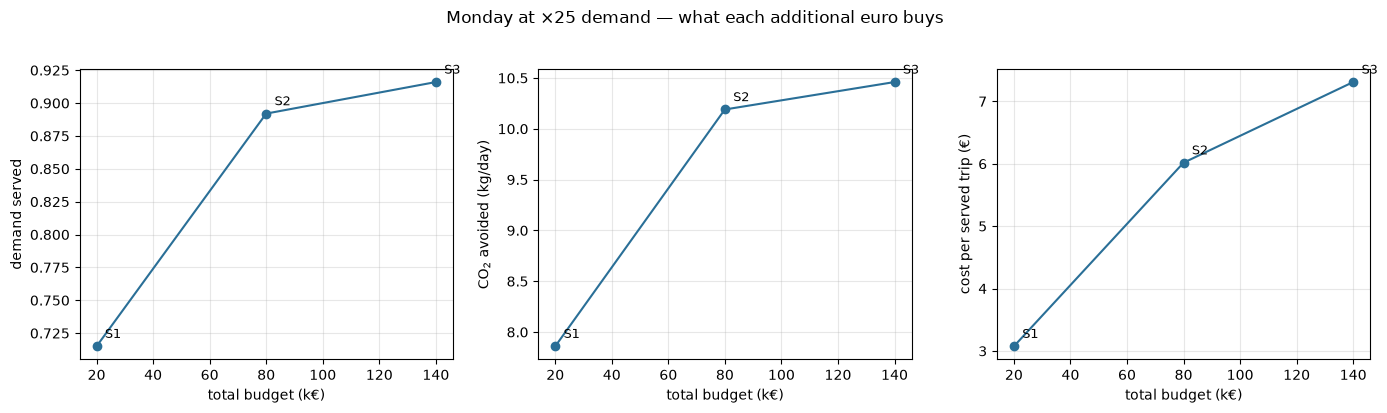

In [17]:
import matplotlib.pyplot as plt

growth = summary[(summary["day"] == "monday_x25")
                 & summary["scenario"].str.startswith("S")].sort_values("budget_eur")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (column, label) in zip(axes, [
        ("served_ratio", "demand served"),
        ("co2_kg_per_day", "CO$_2$ avoided (kg/day)"),
        ("cost_per_served_trip_eur", "cost per served trip (€)")]):
    ax.plot(growth["budget_eur"] / 1000, growth[column], "o-", color="#2a6f97")
    for _, row in growth.iterrows():
        ax.annotate(row["scenario"].split("_")[0],
                    (row["budget_eur"] / 1000, row[column]),
                    textcoords="offset points", xytext=(6, 6), fontsize=9)
    ax.set_xlabel("total budget (k€)")
    ax.set_ylabel(label)
    ax.grid(alpha=.3)

fig.suptitle("Monday at ×25 demand — what each additional euro buys", y=1.02)
fig.tight_layout()
plt.show()

## Step 9 — What was written

Everything the interactive front-end needs is now a static JSON contract under
`demo/experiments/results/<scenario>/`, so the page can stay a purely static site fed by
files this notebook produces offline:

- **`stations.json`** — the design to draw on the map.
- **`instance.json`** — the instance the model actually solved, slimmed: 56 buildable
  cells, 100 candidate stations, the 1,453-trip demand by period. Read by
  `--mode instance` and by `baseline.py`.
- **`model_plan.json`** — the solver's full decision, one level below `metrics.json`'s
  summary: per-candidate built/capacity/inventory by period, rebalancing moves and
  truck dispatches by period, per-OD path assignments with the stations they use.
  Written by the next Gurobi run (the Phase B export in `run_scenario`).
- **`results/shared/bike_arcs.json`** — the model's OSM-routed distances/times between
  candidate stations; one file, shared by all three scenarios since their candidate
  geography is identical. Also written by the next Gurobi run.
- **`sim_<day>.json`** — the hour-by-hour animation source: served/unserved counts, fill
  ratios, empty/full stations per hour, truck rounds; `sim_instance.json` additionally
  carries a `model_view` block (utilisation, borrowable/returnable rates, count-based
  `covered_od_ratio`) computed the way the model itself defines those metrics.
- **`kpis.json`** — the scorecard shown after the day runs; its `instance` day carries
  a `comparison` block against `metrics.json` when one is present.
- **`metrics.json`** — the model's own view (`covered_od_ratio`, time gains, modal flows,
  objective value), merged into the KPIs.

The check below confirms the placeholder stamp is gone: every `metrics.json` should now
report `placeholder: False`, and no `kpis.json` should carry `placeholder_model_results`.


In [18]:
rows = []
for directory in sorted(RESULTS_DIR.iterdir()):
    if not directory.is_dir() or directory.name == "shared":
        continue
    metrics_file = directory / "metrics.json"
    kpis_file = directory / "kpis.json"
    if not kpis_file.is_file():
        continue
    metrics = json.loads(metrics_file.read_text()) if metrics_file.is_file() else {}
    kpis = json.loads(kpis_file.read_text())
    rows.append({
        "results directory": directory.name,
        "files": len(list(directory.glob("*.json"))),
        "has instance.json": (directory / "instance.json").is_file(),
        "has model_plan.json": (directory / "model_plan.json").is_file(),
        "days simulated": ", ".join(sorted(kpis["days"])),
        "model metrics": "real optimiser run" if metrics and not metrics.get("placeholder")
                         else ("PLACEHOLDER" if metrics else "none (baseline)"),
        "placeholder flag in kpis": kpis.get("placeholder_model_results", False),
    })

bike_arcs_file = RESULTS_DIR / "shared" / "bike_arcs.json"
print("results/shared/bike_arcs.json:",
      "present" if bike_arcs_file.is_file() else "missing — written by the next Gurobi run")

pd.DataFrame(rows)


results/shared/bike_arcs.json: present


,results directory,files,has instance.json,has model_plan.json,days simulated,model metrics,placeholder flag in kpis
0,S1_essential,9,True,True,"instance, monday, monday_x25, sunday",real optimiser run,False
1,S2_balanced,9,True,True,"instance, monday, monday_x25, sunday",real optimiser run,False
2,S3_ambitious,9,True,True,"instance, monday, monday_x25, sunday",real optimiser run,False
3,baseline_20k,6,False,False,"instance, monday, monday_x25, sunday",none (baseline),False


### Reproducibility

- The frozen model is untouched: `git diff -- 'network-design-bss/src/**/*.py'` prints
  nothing after this notebook runs. Verify it in the cell below.
- The scenario parameters that produced each design are recorded inside its own
  `stations.json` and `metrics.json`, under `run.model_parameters`, together with the
  solver status, the MIP gap and the wall clock — so a result file can be audited without
  this notebook.
- Every result also records which version of the frozen model produced it:
  `run.src_commit` (the last commit that touched `network-design-bss/src/`) and
  `run.repo_commit` (this repository's `HEAD` at run time), inside `metrics.json`.
  Printed for every scenario below.
- Sampling is seeded, so a scenario replays identically in front of an audience.


In [19]:
import subprocess

diff = subprocess.run(
    ["git", "diff", "HEAD", "--stat", "--", "network-design-bss/src"],
    cwd=REPO, capture_output=True, text=True).stdout.strip()
print(diff or "clean — the frozen model was not modified")

print()
for directory in ALL_DIRS:
    metrics_file = directory / "metrics.json"
    if not metrics_file.is_file():
        continue
    run = json.loads(metrics_file.read_text())["run"]
    src_commit = run.get("src_commit") or "n/a"
    repo_commit = run.get("repo_commit") or "n/a"
    print(f"{directory.name:<16} src_commit={src_commit[:10]}  repo_commit={repo_commit[:10]}")


clean — the frozen model was not modified

S1_essential     src_commit=d75a72f66e  repo_commit=77111e8e25
S2_balanced      src_commit=d75a72f66e  repo_commit=77111e8e25
S3_ambitious     src_commit=d75a72f66e  repo_commit=77111e8e25


### Still to calibrate before public use

Recorded here so the numbers above are never read as more certain than they are; the full
register is in [`METHODS.md`](../demo/experiments/METHODS.md) §4.

- Mode-substitution and fallback shares — literature values from memory, uncited.
- Emission factors and equivalences — mobitool-style, to confirm against a citable Swiss source.
- Fare (2 €), maintenance (0.50 €/bike/day), amortisation (8 y) — operator figures needed.
- The UTC reading of the trip timestamps — cross-validated against PT peaks above, but
  still awaiting confirmation by the data producer.
- Budget-vs-demand scale: at the observed ~11.5 trips/day every budget saturates coverage,
  which is why the scenarios only separate under the ×25 hypothesis. The `instance` day
  above (Steps 3–8) is the demo's current answer — replay the model's own day instead of
  the observed one — but it does not resolve the question below.
- **UPSTREAM — demand scale** (`.specs/demo-pipeline/findings.md` #1, for Zhenyu Wu):
  is `od.csv`'s flow meant as one planning day, or a multi-month-horizon total? The
  `instance` day sidesteps this rather than answering it; the answer decides whether
  that 1,453-trip day is itself the right scale to show an audience, or whether the
  observed ~11.5 trips/day is, once the model can be resized to match it.
- **UPSTREAM — haversine argument order** (`.specs/demo-pipeline/findings.md` #2, for
  Zhenyu Wu): `network-design-bss/src/util/util.py`'s `haversine(coord1, coord2)` reads
  `coord[0]` as latitude while `Node.coordinate` stores `(lon, lat)`, overstating
  Geneva's east–west distances by up to ~20 % wherever it decides catchment membership.
  The demo's own geometry keeps the correct argument order rather than reproducing the
  bug, so a small, documented divergence from the model's own catchment figures remains
  until this is fixed upstream.
